<a href="https://colab.research.google.com/github/SUPRAJ29DB/machine_learning_01/blob/main/randomforest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from google.colab import files
file=files.upload()

Saving large_classification_dataset.csv to large_classification_dataset.csv


In [3]:
import io
filename=next(iter(file))
df=pd.read_csv(io.StringIO(file[filename].decode('utf-8')))
df.head()

,Student_ID,Hours_Studied,Attendance,Assignment_Score,Previous_Result,Final_Result
0,72230,6,99,85,Pass,Pass
1,53592,5,87,68,Fail,Pass
2,21912,9,79,65,Fail,Pass
3,76933,8,41,52,Fail,Pass
4,13964,1,80,56,Fail,Fail


In [4]:
x = df.drop(columns=['Final_Result'])
y = df['Final_Result']

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=0)

xtrain = pd.get_dummies(xtrain, columns=['Previous_Result'], drop_first=True)
xtest = pd.get_dummies(xtest, columns=['Previous_Result'], drop_first=True)

# Ensure consistent columns between xtrain and xtest after one-hot encoding
missing_cols_in_xtest = set(xtrain.columns) - set(xtest.columns)
for c in missing_cols_in_xtest:
    xtest[c] = 0
xtest = xtest[xtrain.columns]

st= StandardScaler()
xtrain_scaled = st.fit_transform(xtrain)
xtest_scaled = st.transform(xtest)

xtrain = pd.DataFrame(xtrain_scaled, columns=xtrain.columns, index=xtrain.index)
xtest = pd.DataFrame(xtest_scaled, columns=xtest.columns, index=xtest.index)

In [9]:
from sklearn.ensemble import RandomForestClassifier
rd= RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
rd.fit(xtrain,ytrain)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [10]:
ypred=rd.predict(xtest)

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score, precision_score, recall_score
import numpy as np

print("========== Random Forest Classifier ==========\n")

# Accuracy
print("Accuracy Score:")
print(accuracy_score(ytest, ypred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(ytest, ypred))

# Classification Report
print("\nClassification Report:")
print(classification_report(ytest, ypred))

# Precision Score
print("Precision Score:")
print(precision_score(ytest, ypred, pos_label='Pass'))

# Recall Score
print("\nRecall Score:")
print(recall_score(ytest, ypred, pos_label='Pass'))

# F1 Score
print("\nF1 Score:")
print(f1_score(ytest, ypred, pos_label='Pass'))

# Convert ytest to numerical labels for ROC functions
ytest_numeric = ytest.map({'Fail': 0, 'Pass': 1})

# ROC-AUC Score
print("\nROC-AUC Score:")
# Get probabilities for the 'Pass' class
classes = rd.classes_
pass_class_index = np.where(classes == 'Pass')[0][0]
y_pred_proba_pass = rd.predict_proba(xtest)[:, pass_class_index]

print(roc_auc_score(ytest_numeric, y_pred_proba_pass))

# ROC Curve
fpr, tpr, threshold = roc_curve(ytest_numeric, y_pred_proba_pass)

print("\nFalse Positive Rate:")
print(fpr)

print("\nTrue Positive Rate:")
print(tpr)

========== Random Forest Classifier ==========

Accuracy Score:
0.9905

Confusion Matrix:
[[ 177   11]
 [   8 1804]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.96      0.94      0.95       188
        Pass       0.99      1.00      0.99      1812

    accuracy                           0.99      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.99      0.99      0.99      2000

Precision Score:
0.9939393939393939

Recall Score:
0.9955849889624724

F1 Score:
0.9947615108905431

ROC-AUC Score:
0.9961207200225448

False Positive Rate:
[0.         0.00531915 0.0106383  0.0212766  0.04255319 0.05851064
 0.09042553 0.14893617 0.21276596 0.29787234 0.45744681 1.        ]

True Positive Rate:
[0.         0.93487859 0.97130243 0.98675497 0.99227373 0.99558499
 0.99834437 0.99889625 0.99944812 1.         1.         1.        ]


### ROC Curve Visualization

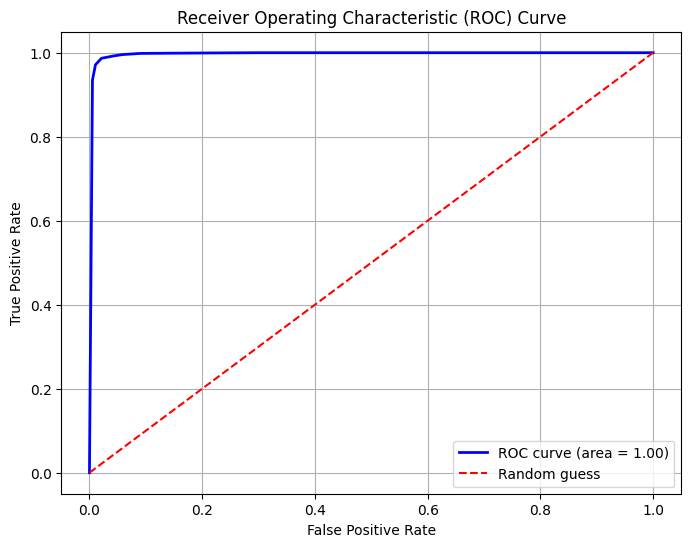

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(ytest_numeric, y_pred_proba_pass))
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Scatter Plot: Hours Studied vs. Assignment Score by Final Result

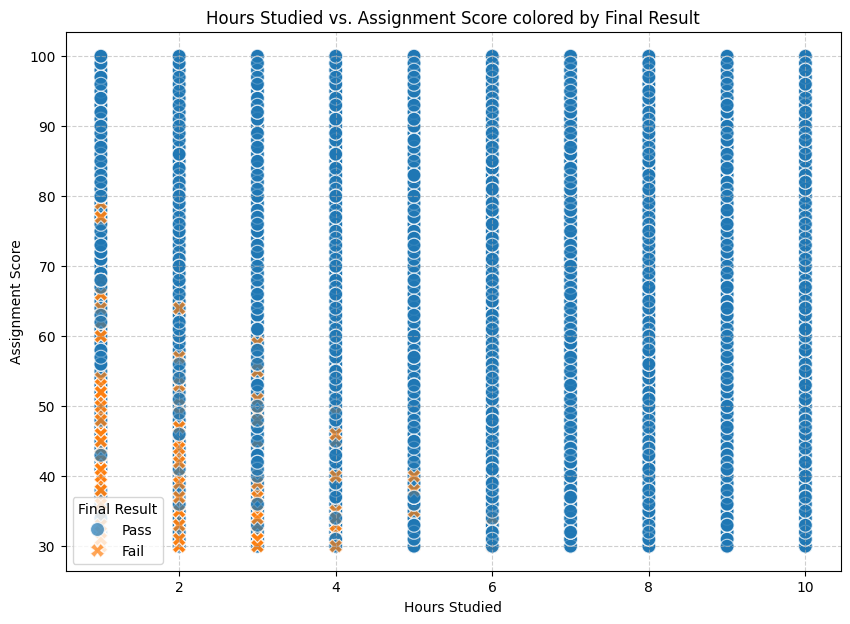

In [15]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Hours_Studied', y='Assignment_Score', hue='Final_Result', style='Final_Result', s=100, alpha=0.7)
plt.title('Hours Studied vs. Assignment Score colored by Final Result')
plt.xlabel('Hours Studied')
plt.ylabel('Assignment Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Final Result')
plt.show()